# Binary Classification

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, RandomizedSearchCV
from sklearn.datasets import fetch_openml
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

In [2]:
mnist_784 = fetch_openml("mnist_784", as_frame=False)
x, y = mnist_784.data, mnist_784.target
x, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

In [4]:
xTrain, yTrain, xTest, yTest = x[:60000, :], y[:60000], x[60000:, :], y[60000:]
xTrain, yTrain, xTest, yTest 

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784)),
 array(['5', '0', '4', ..., '5', '6', '8'], shape=(60000,), dtype=object),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784)),
 array(['7', '2', '1', ..., '4', '5', '6'], shape=(10000,), dtype=object))

In [5]:
def displayImage(imageArray):
    image = imageArray.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

def genRandomIndex():
    return np.random.randint(low=0, high=60000, dtype=int)

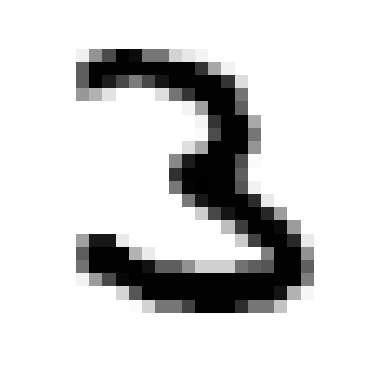

In [6]:
displayImage(xTrain[genRandomIndex()])

In [7]:
yTrain = (yTrain=='7')
yTest = (yTest == '7')
yTrain, yTest

(array([False, False, False, ..., False, False, False], shape=(60000,)),
 array([ True, False, False, ..., False, False, False], shape=(10000,)))

In [8]:
classificationModel = RandomForestClassifier(random_state=67)
score = cross_val_score(classificationModel, xTrain, yTrain, scoring="accuracy", cv=10, n_jobs=-1) # Not a good way to measure

In [9]:
pd.Series(score).describe()

count    10.000000
mean      0.989517
std       0.001888
min       0.987500
25%       0.988167
50%       0.988917
75%       0.990125
max       0.993167
dtype: float64

In [141]:
yPredictOnUnSeenData = cross_val_predict(classificationModel, xTrain, yTrain, cv=5, n_jobs=-1)

In [142]:
print(f"precision Score: {precision_score(yTrain, yPredictOnUnSeenData)*100}%")
print(f"Recall score: {recall_score(yTrain, yPredictOnUnSeenData)*100}%")
print(f"F1 score: {f1_score(yTrain, yPredictOnUnSeenData)*100}%")
print(f"Under he ROC curve: {roc_auc_score(yTrain, yPredictOnUnSeenData)*100}%")

precision Score: 98.750433877126%
Recall score: 90.8220271348763%
F1 score: 94.62043734929742%
Under he ROC curve: 95.34401812685009%


In [25]:
classificationModel = RandomForestClassifier(random_state=67)
yScorePredictOnUnSeenData = cross_val_predict(classificationModel, xTrain, yTrain, cv=5, n_jobs=-1, method="predict_proba")
yScorePredictOnUnSeenData

array([[0.98, 0.02],
       [1.  , 0.  ],
       [0.91, 0.09],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.93, 0.07]], shape=(60000, 2))

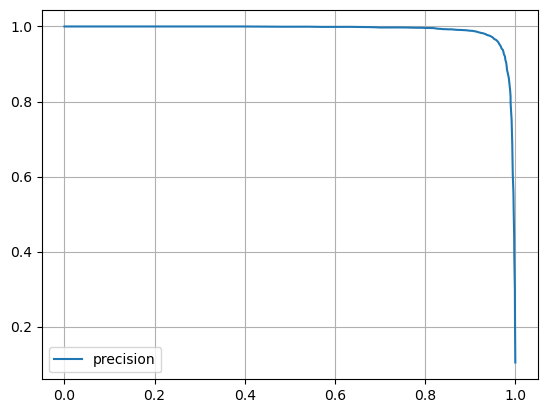

In [26]:
precision, recall, thresholds = precision_recall_curve(yTrain, yScorePredictOnUnSeenData[:,1])
plt.plot(recall, precision, label="precision")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
xGBoostModel = XGBClassifier(
    tree_method="hist",
    n_jobs=11,
    eval_metric="logloss",
    random_state=42
    )

In [23]:
yXGBoostScore = cross_val_predict(xGBoostModel, xTrain, yTrain, method="predict_proba", cv=5, n_jobs=-1)
yXGBoostScore

array([[9.99998152e-01, 1.85299109e-06],
       [9.99997139e-01, 2.85843612e-06],
       [9.74185586e-01, 2.58144420e-02],
       ...,
       [9.99980450e-01, 1.95561479e-05],
       [9.99993980e-01, 6.01288002e-06],
       [9.99892950e-01, 1.07032494e-04]], shape=(60000, 2), dtype=float32)

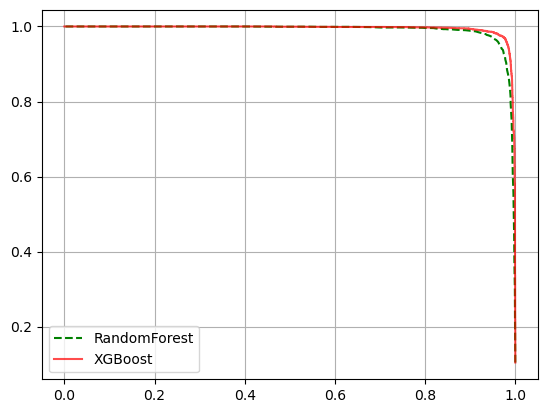

In [27]:
precisionXG, recallXG, thresholdsXG = precision_recall_curve(yTrain, yXGBoostScore[:,1])
plt.plot(recall, precision, "g--", label="RandomForest")
plt.plot(recallXG, precisionXG, 'r', label="XGBoost", alpha=0.7)
plt.legend()
plt.grid()
plt.show()

In [148]:
yXGBoostPredictOnUnSeenData = cross_val_predict(xGBoostModel, xTrain, yTrain, cv=5, n_jobs=-1)

In [149]:
print(f"precision Score: {precision_score(yTrain, yXGBoostPredictOnUnSeenData)*100}%")
print(f"Recall score: {recall_score(yTrain, yXGBoostPredictOnUnSeenData)*100}%")
print(f"F1 score: {f1_score(yTrain, yXGBoostPredictOnUnSeenData)*100}%")
print(f"Under he ROC curve: {roc_auc_score(yTrain, yXGBoostPredictOnUnSeenData)*100}%")
print(f"Accuracy: {accuracy_score(yTrain, yXGBoostPredictOnUnSeenData)*100}%")

precision Score: 98.15117801047121%
Recall score: 95.75418994413408%
F1 score: 96.93786862729256%
Under he ROC curve: 97.77194935003298%
Accuracy: 99.36833333333334%


In [150]:
param_dist = {
    "n_estimators": randint(795, 800),
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 8),
    "gamma": randint(0, 5),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.6, 0.4),
    "learning_rate": uniform(0.01, 0.04),
    "reg_alpha": randint(0, 20),
    "reg_lambda": randint(1, 50),
}
searchModel = RandomizedSearchCV(estimator=xGBoostModel, param_distributions=param_dist, cv=5, refit=True, scoring="accuracy", n_jobs=10, n_iter=50, random_state=67, verbose=3)

In [152]:
searchModel.fit(xTrain, yTrain)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[CV 5/5] END colsample_bytree=0.8183405719739915, gamma=2, learning_rate=0.04805411776479858, max_depth=4, min_child_weight=2, n_estimators=798, reg_alpha=3, reg_lambda=23, subsample=0.8158833343128127;, score=0.993 total time= 2.0min
[CV 4/5] END colsample_bytree=0.8183405719739915, gamma=2, learning_rate=0.04805411776479858, max_depth=4, min_child_weight=2, n_estimators=798, reg_alpha=3, reg_lambda=23, subsample=0.8158833343128127;, score=0.989 total time= 2.8min
[CV 2/5] END colsample_bytree=0.8183405719739915, gamma=2, learning_rate=0.04805411776479858, max_depth=4, min_child_weight=2, n_estimators=798, reg_alpha=3, reg_lambda=23, subsample=0.8158833343128127;, score=0.992 total time= 2.8min
[CV 3/5] END colsample_bytree=0.8183405719739915, gamma=2, learning_rate=0.04805411776479858, max_depth=4, min_child_weight=2, n_estimators=798, reg_alpha=3, reg_lambda=23, subsample=0.8158833343128127;, score=0.991 total time= 2.9min
[CV 1/5] END colsample_bytree=0.8183405719739915, gamma=2, l

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....x7f7dbae7cd10>, 'gamma': <scipy.stats....x7f7db91104b0>, 'learning_rate': <scipy.stats....x7f7dba8d1650>, 'max_depth': <scipy.stats....x7f7dba8dc730>, ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,10
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [153]:
resultDf = pd.DataFrame(searchModel.cv_results_)
resultDf.set_index("rank_test_score", inplace=True)
resultDf.sort_index(inplace=True)
resultDf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,,,
1,272.630021,25.265254,0.296059,0.053313,0.840770,0,0.042106,8,6,799,2,17,0.988925,"{'colsample_bytree': 0.8407699229007761, 'gamm...",0.993917,0.993833,0.993333,0.991583,0.994000,0.993333,0.000905
2,353.775737,25.792101,0.364124,0.065789,0.971591,0,0.029897,8,3,795,1,13,0.978335,"{'colsample_bytree': 0.9715911522104105, 'gamm...",0.993750,0.993917,0.993000,0.992083,0.993833,0.993317,0.000698
3,363.922866,6.612545,0.426689,0.018747,0.994021,0,0.034191,9,3,797,3,14,0.955158,"{'colsample_bytree': 0.9940213119549179, 'gamm...",0.993583,0.993667,0.993000,0.991583,0.993750,0.993117,0.000811
4,149.190933,27.387470,0.144032,0.044217,0.852754,2,0.028847,8,4,795,1,4,0.865014,"{'colsample_bytree': 0.8527543136024479, 'gamm...",0.993583,0.993000,0.992333,0.991167,0.993667,0.992750,0.000925
5,190.391195,29.453502,0.146784,0.043563,0.986023,0,0.043876,4,1,797,5,15,0.789680,"{'colsample_bytree': 0.9860232214228468, 'gamm...",0.993417,0.993417,0.992333,0.990833,0.993667,0.992733,0.001056
6,173.654254,5.315697,0.150865,0.031579,0.780138,2,0.044160,6,3,798,2,22,0.756092,"{'colsample_bytree': 0.7801382273455373, 'gamm...",0.992833,0.991833,0.991333,0.990417,0.993417,0.991967,0.001065
7,221.101230,3.001282,0.131048,0.005397,0.950957,0,0.027497,8,4,798,17,17,0.916148,"{'colsample_bytree': 0.9509569452172776, 'gamm...",0.992417,0.992167,0.991167,0.990083,0.992833,0.991733,0.000991
8,234.250078,21.313400,0.282183,0.055340,0.685260,0,0.046752,9,7,799,14,46,0.775621,"{'colsample_bytree': 0.6852599434737423, 'gamm...",0.992500,0.991833,0.991000,0.989667,0.993500,0.991700,0.001306
8,258.836416,17.568083,0.231357,0.069330,0.911794,0,0.034341,6,3,798,14,49,0.944437,"{'colsample_bytree': 0.9117939179794724, 'gamm...",0.993000,0.992167,0.990750,0.989417,0.993167,0.991700,0.001427


In [158]:
finalModel = searchModel.best_estimator_
yPredOnfinalModel = cross_val_predict(finalModel, xTrain, yTrain, cv=5, n_jobs=-1)

In [159]:
print(f"precision Score: {precision_score(yTrain, yPredOnfinalModel)*100}%")
print(f"Recall score: {recall_score(yTrain, yPredOnfinalModel)*100}%")
print(f"F1 score: {f1_score(yTrain, yPredOnfinalModel)*100}%")
print(f"Under he ROC curve: {roc_auc_score(yTrain, yPredOnfinalModel)*100}%")
print(f"Accuracy: {accuracy_score(yTrain, yPredOnfinalModel)*100}%")

precision Score: 98.0974249630966%
Recall score: 95.46687948922585%
F1 score: 96.76427762497978%
Under he ROC curve: 97.62550264588769%
Accuracy: 99.33333333333333%


In [17]:
xGBoostHeavyModel = XGBClassifier(
    tree_method="hist",
    n_jobs=11,
    eval_metric="logloss",
    random_state=42,
    learning_rate = 0.001,
    n_estimators= 36000,
    )

In [18]:
finalPredictScore = cross_val_predict(xGBoostHeavyModel, xTrain, yTrain, cv=5, n_jobs=-1, method="predict_proba")

In [46]:
plt.figure(figsize=(100,100))
precisionFinal, recallFinal, thresholdsFinal = precision_recall_curve(yTrain, finalPredictScore[:,1])
plt.plot(recallFinal, precisionFinal, 'r', label="XGBoostHeavy", alpha=1, linewidth=2)
plt.plot(recallXG, precisionXG, 'g--', label="XGBoost", linewidth=2, alpha=0.7)
plt.grid(True)
plt.legend()
plt.show()

In [190]:
indexOf90p = (precisionFinal >= 0.9763339999999999999999).argmax() # 99% precision
tunedThresholds = thresholdsFinal[indexOf90p]
tunedThresholds

np.float32(0.24231002)

In [196]:
finalPredict = (finalPredictScore[:,1] >= tunedThresholds)
finalPredict

array([False, False, False, ..., False, False, False], shape=(60000,))

In [197]:
print(f"precision Score: {precision_score(yTrain, finalPredict)*100}%")
print(f"Recall score: {recall_score(yTrain, finalPredict)*100}%")
print(f"F1 score: {f1_score(yTrain, finalPredict)*100}%")
print(f"Under he ROC curve: {roc_auc_score(yTrain, finalPredict)*100}%")
print(f"Accuracy: {accuracy_score(yTrain, finalPredict)*100}%")

precision Score: 97.63389288569144%
Recall score: 97.4780526735834%
F1 score: 97.55591054313099%
Under he ROC curve: 98.601313486694%
Accuracy: 99.49%


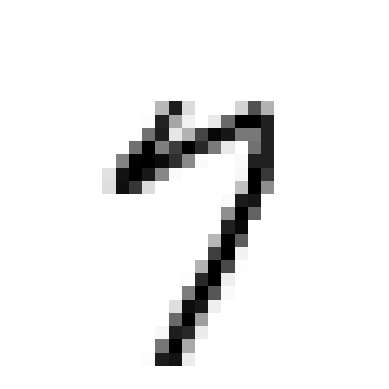

Is this a image of 7? 
AI: True	Correct Answer: True
---------------Correct---------------


In [377]:
randomIndex = genRandomIndex()
displayImage(xTrain[randomIndex])
print(f"Is this a image of 7? \nAI: {finalPredict[randomIndex]}\tCorrect Answer: {yTrain[randomIndex]}")
if(finalPredict[randomIndex] == yTrain[randomIndex]):
    print("---------------Correct---------------")
else:
    print("---------------Wrong!----------------")